<a href="https://colab.research.google.com/github/rudralpha10/PrimeTrade/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(211224, 19)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

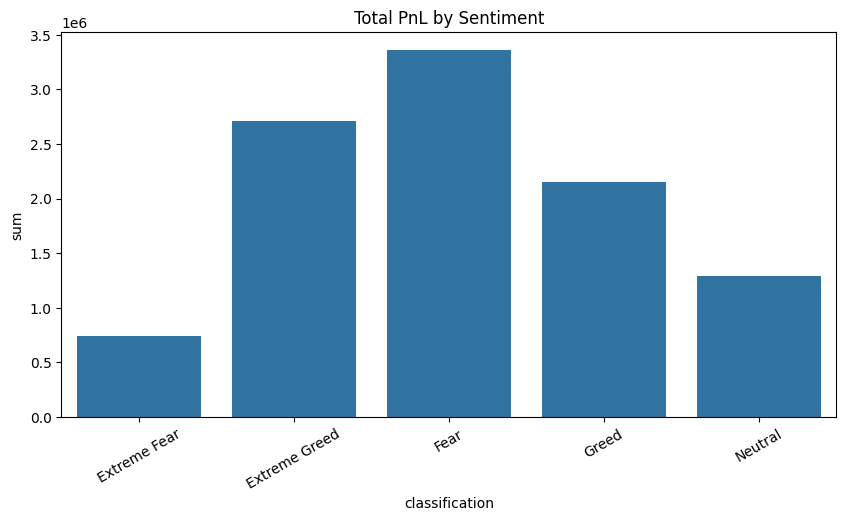

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


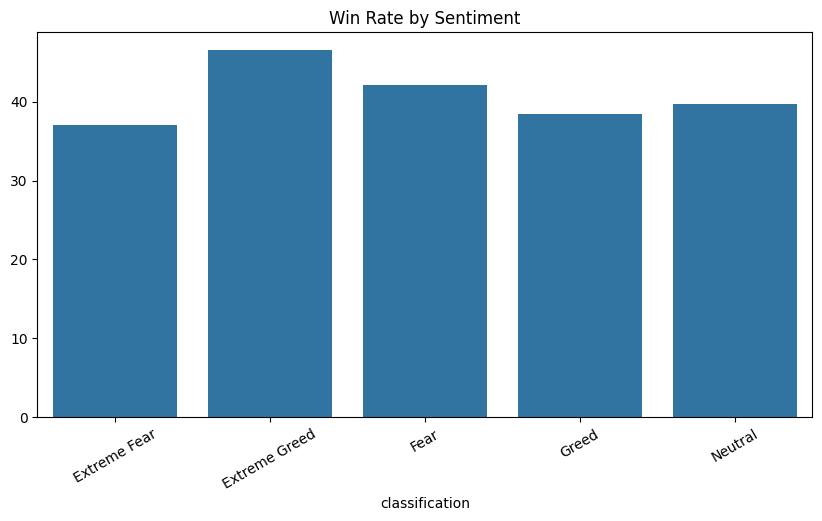

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


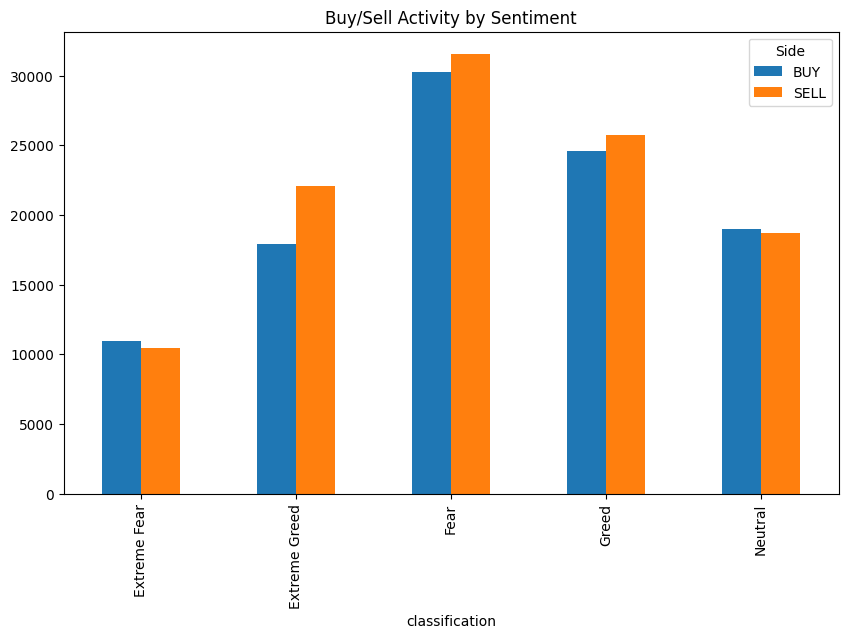

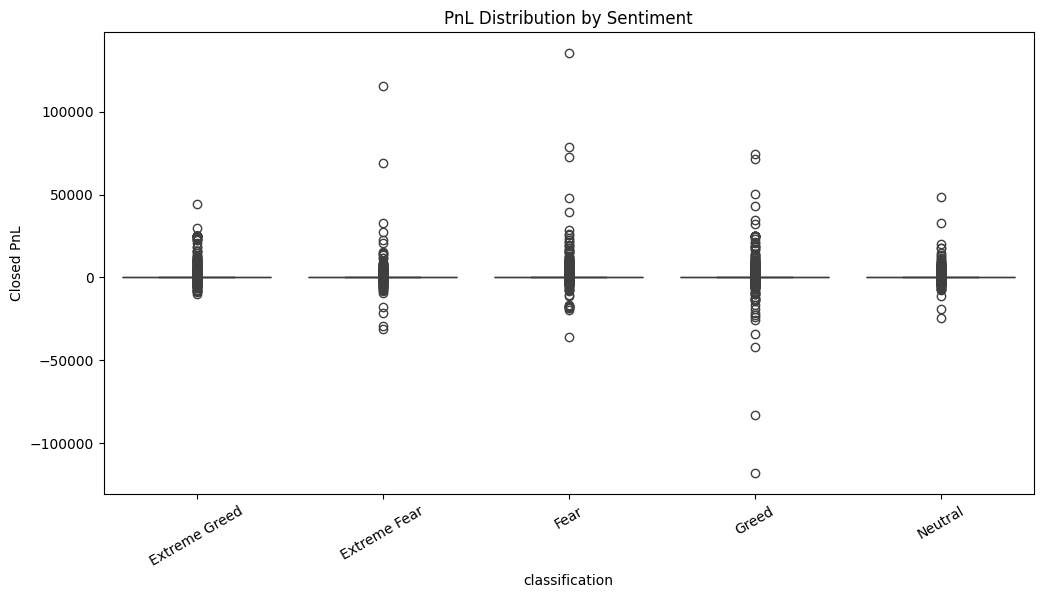

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

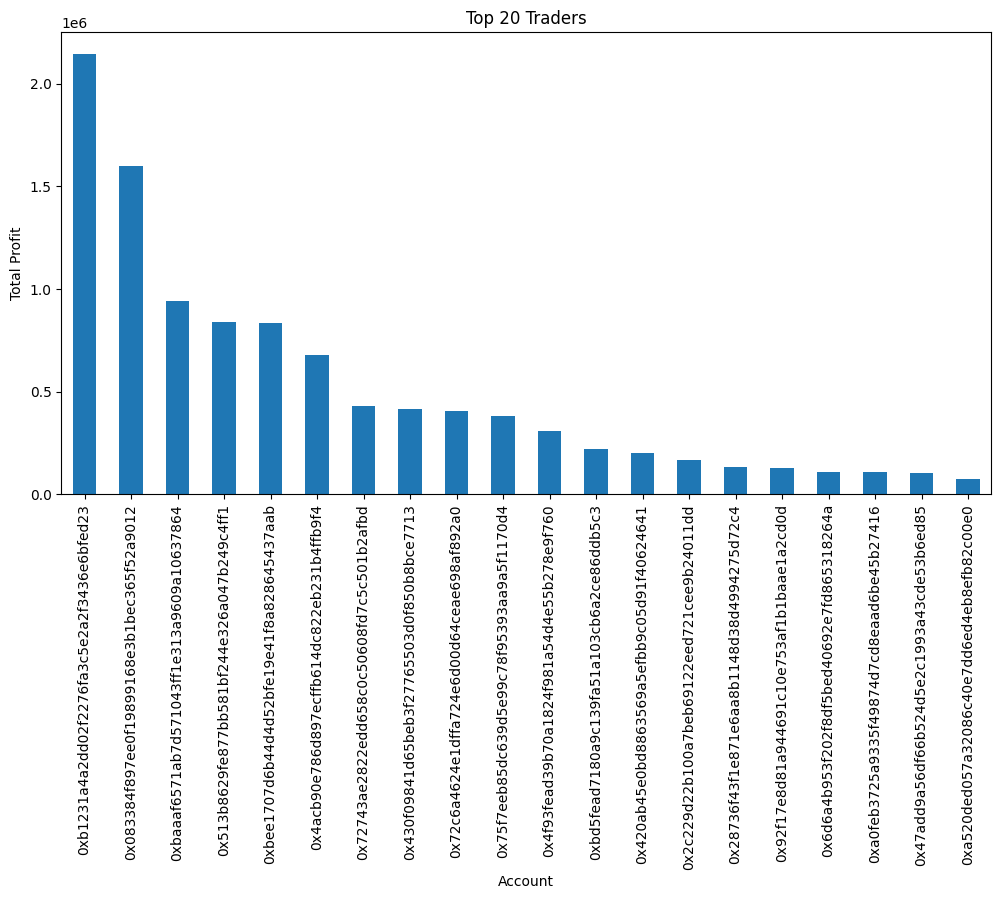

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


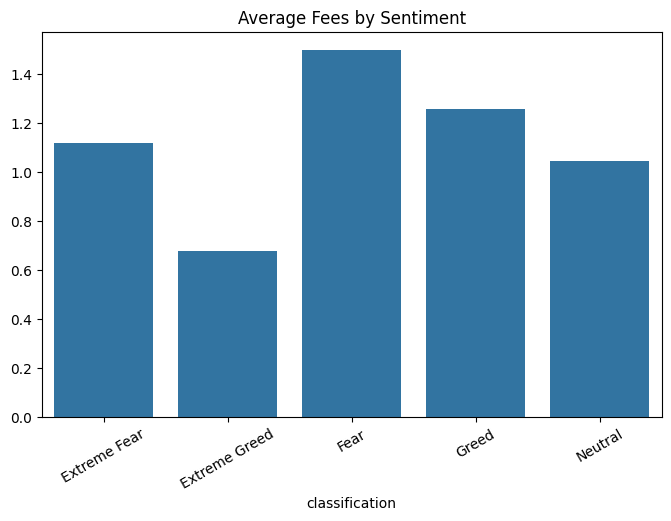

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


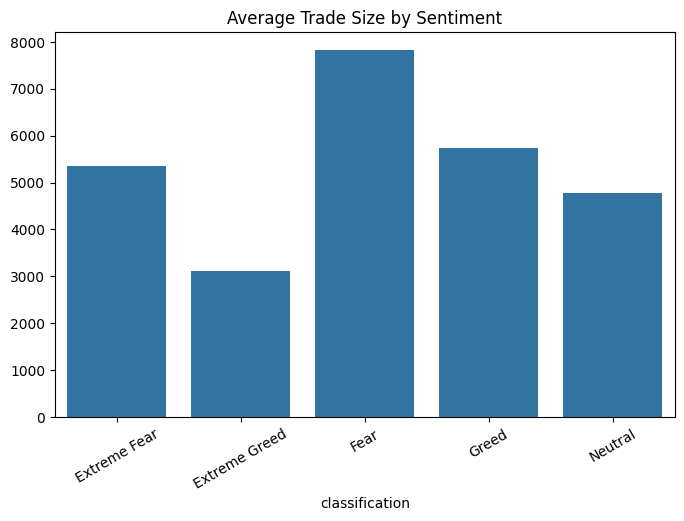

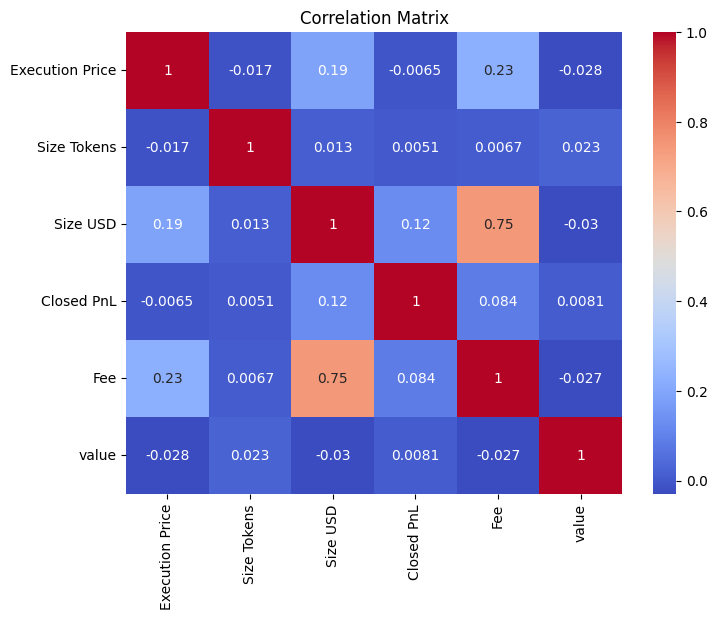

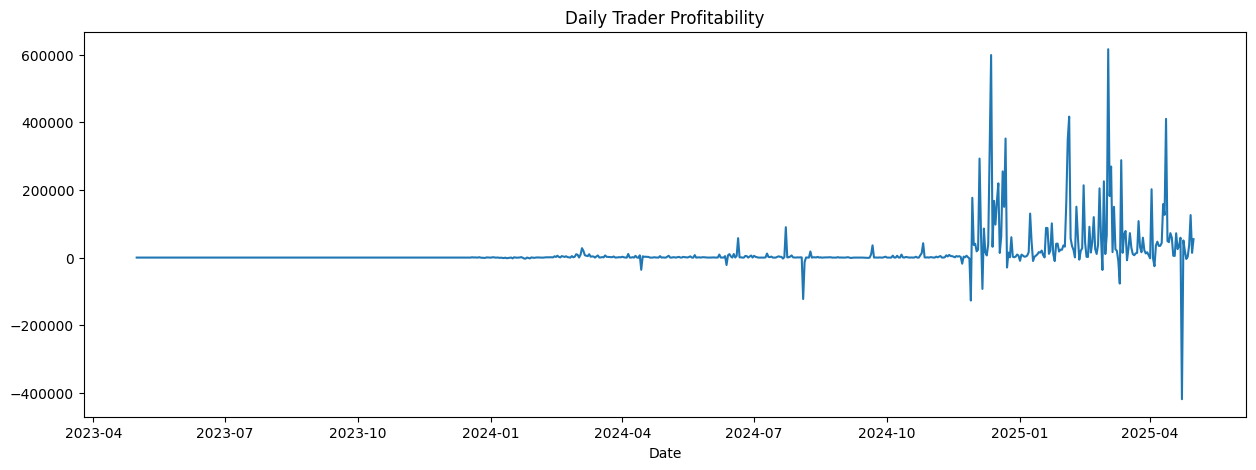

classification
Extreme Fear     57.714087
Extreme Greed    73.905872
Fear             62.885725
Greed            66.215774
Neutral          39.781718
Name: Closed PnL, dtype: float64
               Closed PnL                                  Fee     Size USD  \
                     mean           sum          std      mean         mean   
classification                                                                
Extreme Fear    34.537862  7.391102e+05  1136.056091  1.116291  5349.731843   
Extreme Greed   67.892861  2.715171e+06   766.828294  0.675902  3112.251565   
Fear            54.290400  3.357155e+06   935.355438  1.495172  7816.109931   
Greed           42.743559  2.150129e+06  1116.028390  1.254372  5736.884375   
Neutral         34.307718  1.292921e+06   517.122220  1.044798  4782.732661   

               Account  
                 count  
classification          
Extreme Fear     21400  
Extreme Greed    39992  
Fear             61837  
Greed            50303  
Neutral  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
).dt.date

sentiment["Date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

df = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print(df.shape)

print(df.head())

print(df["classification"].value_counts())

pnl_summary = df.groupby(
    "classification"
)["Closed PnL"].agg(
    ["mean", "sum", "count", "std"]
)

print(pnl_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=pnl_summary.index,
    y=pnl_summary["sum"]
)

plt.xticks(rotation=30)
plt.title("Total PnL by Sentiment")
plt.savefig("pnl_by_sentiment.png", bbox_inches="tight")
plt.show()

df["Win"] = df["Closed PnL"] > 0

win_rate = (
    df.groupby("classification")["Win"]
    .mean() * 100
)

print(win_rate)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title("Win Rate by Sentiment")
plt.xticks(rotation=30)
plt.savefig("winrate.png", bbox_inches="tight")
plt.show()

trade_activity = pd.crosstab(
    df["classification"],
    df["Side"]
)

print(trade_activity)

trade_activity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Buy/Sell Activity by Sentiment")
plt.savefig("buy_sell.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="classification",
    y="Closed PnL"
)

plt.xticks(rotation=30)
plt.title("PnL Distribution by Sentiment")
plt.savefig("pnl_distribution.png", bbox_inches="tight")
plt.show()

top_traders = (
    df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)

print(top_traders.head(20))

plt.figure(figsize=(12, 6))

top_traders.head(20).plot(
    kind="bar"
)

plt.title("Top 20 Traders")
plt.ylabel("Total Profit")
plt.savefig("top_traders.png", bbox_inches="tight")
plt.show()

fee_analysis = (
    df.groupby("classification")["Fee"]
    .mean()
)

print(fee_analysis)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fee_analysis.index,
    y=fee_analysis.values
)

plt.xticks(rotation=30)
plt.title("Average Fees by Sentiment")
plt.savefig("fees_by_sentiment.png", bbox_inches="tight")
plt.show()

size_analysis = (
    df.groupby("classification")["Size USD"]
    .mean()
)

print(size_analysis)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=size_analysis.index,
    y=size_analysis.values
)

plt.xticks(rotation=30)
plt.title("Average Trade Size by Sentiment")
plt.savefig("trade_size.png", bbox_inches="tight")
plt.show()

corr_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee",
    "value"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

daily_profit = (
    df.groupby("Date")["Closed PnL"]
    .sum()
)

plt.figure(figsize=(15, 5))

daily_profit.plot()

plt.title("Daily Trader Profitability")
plt.savefig("daily_profitability.png", bbox_inches="tight")
plt.show()

top_accounts = top_traders.head(20).index

top20 = df[
    df["Account"].isin(top_accounts)
]

top20_sentiment = top20.groupby(
    "classification"
)["Closed PnL"].mean()

print(top20_sentiment)

summary = df.groupby(
    "classification"
).agg({
    "Closed PnL": ["mean", "sum", "std"],
    "Fee": "mean",
    "Size USD": "mean",
    "Account": "count"
})

print(summary)

summary.to_csv("sentiment_summary.csv")

print("Analysis Complete")